In [1]:
import numpy as np
from scipy.integrate import solve_ivp

step = 100

x = np.linspace(0, 1, step)
x_step = 1/step


def d2(u):
    u = np.concatenate([np.array(u[:1]), u,np.array(u[-1:])])
    return (u[2:] + u[:-2] + -2*u[1:-1])/x_step ** 2

def dxdxu(t, u):
    return d2(u)

y0 = np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)

r = [0, 0.01]
e = np.array(range(11))/1000

y_0 = solve_ivp(dxdxu, r, y0, t_eval = e)

In [2]:
from utils.pde import PDE
from utils.triangulation import Triangulation
from utils.finite_element import LagrangeBasis, FiniteElement
from utils.tensor_network import TensorUnit, TensorNetwork
from utils.solver import DMRG

pde_dxdxu_txt = 'D[2, 0, 0]'
pde_dxdxu = PDE(pde_dxdxu_txt, equal_time_derivative = True)

basis_order = 1
elements = 5
continuity_order = 1
bond_order = 1
delta = 0.001
steps = int(r[-1] // delta)
rounds = 20
alpha = 1

triangulation = Triangulation(np.linspace(0, 1, elements + 1))
basis = LagrangeBasis(1, basis_order)

fe = FiniteElement(triangulation, basis)
fe.set_con_bc_operators(continuity_order)
fe.set_env_bc_operators({0: {1: ([np.array([[0]]), np.array([[[1]]])], 
                                  np.array([[0]]))},
                         elements - 1: {0: ([np.array([[0]]), np.array([[[1]]])], 
                                  np.array([[0]]))}})

fe.calculate_higher_domain_derivatives(2)

tn = TensorNetwork(basis.rank, triangulation.neighbors, fe.domain_derivatives_list, basis.tp_reduce)
tn.set_u_shape(tuple())
tn.set_h_tensor_units([])

y0 = lambda x: np.exp(-100 * (x - 0.5) ** 2) + np.exp(-100 * (x + 0.5) ** 2) + np.exp(-100 * (x - 1.5) ** 2)
rep = fe.fun2rep(y0)
rep = np.broadcast_to(rep[..., None, None], rep.shape + (bond_order,) * (basis.d + 1))
states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

all_reps = [[states.tensor[..., 0, 0].copy()]]
for reps, pde in zip(all_reps, [pde_dxdxu]):
    for i in range(steps):
        print(i)
        pde_operators, pde_power =  tn.get_operators_from_pde(pde.pde, delta, states.copy())
        tn.set_states(states, bond_order)
        tn.set_bcs(fe.con_bc_operators, fe.env_bc_operators, 1)
        tn.set_solver(DMRG())
        tn.set_operators(pde_operators, pde_power)
        states = tn.solve(rounds = rounds, alpha = alpha, env = True)
        reps.append(states.tensor[..., 0, 0].copy())
    states = TensorUnit(rep.copy(), len(rep.shape) - basis.d - 2, [1] * (basis.d + 1), 0)

0
1
2
3
4
5
6
7
8
9


In [3]:
def avg_diff(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

In [4]:
for reps, y in zip(all_reps, [y_0]):
    for j, rep in enumerate(reps):
        print(avg_diff(fe.rep2fun(rep)(x), y.y[..., j]))

0.052740264234334686
0.0836643182597173
0.11772388673522538
0.13584411070855093
0.14468772101760388
0.148244105609772
0.1485335719501604
0.14671395464347245
0.1435111359646281
0.1395723385344928
0.1351549303836726


In [6]:
import numpy as np

basis_orders = np.array([1, 2, 3, 4, 5, 6])
diff_basis_orders = np.array([[0.13062669, 0.0419191 , 0.04633286, 0.08656823, 0.04523925, 0.04451499],
                            [0.13062669, 0.04655005, 0.04010236, 0.0880217 , 0.03099307, 0.03182281],
                            [0.13062669, 0.11139071, 0.03251179, 0.05471848, 0.01799251, 0.01979405],
                            [0.13062669, 0.13515493, 0.02944836, 0.03482391, 0.0122164 , 0.01329857],
                            [0.13062669, 0.13870745, 0.02819064, 0.02440514, 0.00961551, 0.00986379],
                            [0.13062669, 0.13876694, 0.02762301, 0.01871745, 0.00846016, 0.01020412],
                            [0.13062669, 0.13876694, 0.02744478, 0.01732853, 0.00900357, 0.01310771]])

elements = np.array([2, 4, 6, 8, 10])
diff_elements = np.array([[0.19384667, 0.11285691, 0.09206282, 0.07867108, 0.08001384],
                        [0.20448309, 0.11146949, 0.07369322, 0.05652242, 0.05505721],
                        [0.21375863, 0.11018996, 0.04825074, 0.03116911, 0.02657293],
                        [0.22148404, 0.10172779, 0.03493405, 0.01853554, 0.01388503],
                        [0.21953901, 0.09289424, 0.02743651, 0.01232043, 0.0081106 ],
                        [0.21689923, 0.0872841 , 0.02398551, 0.00947169, 0.00561944],
                        [0.21601062, 0.08553034, 0.02315589, 0.00876352, 0.00550492]])

deltas = np.array([0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001])

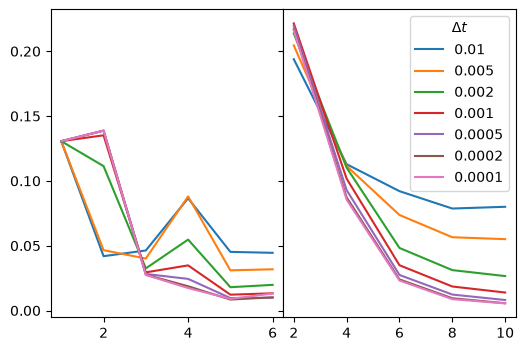

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, sharey = True, sharex = False, figsize = (6, 4))
fig.subplots_adjust(wspace = 0)
for diff_B, diff_N, delta in zip(diff_basis_orders, diff_elements, deltas):
    axs[0].plot(basis_orders, diff_B)
    axs[1].plot(elements, diff_N, label = f'{delta}')
axs[1].legend(title = r'$\Delta t$')
fig.savefig('conv.png', dpi = 400)